In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [11]:
# ============================================================================
# SECTION 1: DATA EXTRACTION
# ============================================================================

# Define assets and date range
ASSETS = {
    'TSLA': {
        'name': 'Tesla Inc.',
        'description': 'High-growth stock in consumer discretionary sector',
        'risk_profile': 'High risk, high potential return',
        'role': 'Growth driver'
    },
    'BND': {
        'name': 'Vanguard Total Bond Market ETF',
        'description': 'Tracks U.S. investment-grade bonds',
        'risk_profile': 'Low risk, stability and income',
        'role': 'Portfolio stabilizer'
    },
    'SPY': {
        'name': 'S&P 500 ETF',
        'description': 'Tracks the S&P 500 Index',
        'risk_profile': 'Moderate risk, broad market exposure',
        'role': 'Market core holding'
    }
}

START_DATE = '2015-01-01'
END_DATE = '2026-06-30'

print("=" * 70)
print("STEP 1: DATA EXTRACTION")
print("=" * 70)
print(f"Date Range: {START_DATE} to {END_DATE}")
print(f"Assets to download: {list(ASSETS.keys())}")

STEP 1: DATA EXTRACTION
Date Range: 2015-01-01 to 2026-06-30
Assets to download: ['TSLA', 'BND', 'SPY']


In [12]:
# Download data
raw_data = {}
print("\nDownloading data...")
for ticker, info in ASSETS.items():
    print(f"  Downloading {info['name']} ({ticker})...")
    stock = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
    raw_data[ticker] = stock
    print(f"    ✅ Downloaded {len(stock)} rows")
    print(f"    Columns: {stock.columns.tolist()}")


    ✅ Downloaded 2888 rows
    Columns: [('Close', 'TSLA'), ('High', 'TSLA'), ('Low', 'TSLA'), ('Open', 'TSLA'), ('Volume', 'TSLA')]
    ✅ Downloaded 2888 rows
    Columns: [('Close', 'BND'), ('High', 'BND'), ('Low', 'BND'), ('Open', 'BND'), ('Volume', 'BND')]
    ✅ Downloaded 2888 rows
    Columns: [('Close', 'SPY'), ('High', 'SPY'), ('Low', 'SPY'), ('Open', 'SPY'), ('Volume', 'SPY')]


In [13]:
# ============================================================================
# SECTION 2: DATA CLEANING PIPELINE
# ============================================================================

print("\n" + "=" * 70)
print("STEP 2: DATA CLEANING PIPELINE")
print("=" * 70)

# --- STEP 2.1: Initial Inspection ---
print("\n[2.1] Initial Data Inspection")
print("-" * 40)
for ticker, df in raw_data.items():
    print(f"\n{ticker}:")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {df.columns.tolist()}")
    print(f"  Date range: {df.index.min()} to {df.index.max()}")


STEP 2: DATA CLEANING PIPELINE

[2.1] Initial Data Inspection
----------------------------------------

TSLA:
  Shape: (2888, 5)
  Columns: [('Close', 'TSLA'), ('High', 'TSLA'), ('Low', 'TSLA'), ('Open', 'TSLA'), ('Volume', 'TSLA')]
  Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00

BND:
  Shape: (2888, 5)
  Columns: [('Close', 'BND'), ('High', 'BND'), ('Low', 'BND'), ('Open', 'BND'), ('Volume', 'BND')]
  Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00

SPY:
  Shape: (2888, 5)
  Columns: [('Close', 'SPY'), ('High', 'SPY'), ('Low', 'SPY'), ('Open', 'SPY'), ('Volume', 'SPY')]
  Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00


In [14]:
# --- STEP 2.2: Check for Missing Values ---
print("\n[2.2] Missing Values Check")
print("-" * 40)
for ticker, df in raw_data.items():
    missing = df.isnull().sum()
    total_missing = missing.sum()
    pct_missing = (total_missing / (df.shape[0] * df.shape[1])) * 100
    print(f"{ticker}: {total_missing} missing values ({pct_missing:.2f}%)")
    if total_missing > 0:
        print(f"  Missing columns: {missing[missing > 0].index.tolist()}")


[2.2] Missing Values Check
----------------------------------------
TSLA: 0 missing values (0.00%)
BND: 0 missing values (0.00%)
SPY: 0 missing values (0.00%)


In [15]:
# --- STEP 2.3: Handle Missing Values ---
print("\n[2.3] Handling Missing Values")
print("-" * 40)
cleaned_data = {}
for ticker, df in raw_data.items():
    print(f"\n{ticker}:")
    # Forward fill (use last known value)
    df_ffill = df.ffill()
    # Backward fill (for any remaining)
    df_cleaned = df_ffill.bfill()
    
    # Verify no missing values
    remaining_missing = df_cleaned.isnull().sum().sum()
    print(f"  Before cleaning: {df.isnull().sum().sum()} missing")
    print(f"  After cleaning: {remaining_missing} missing")
    cleaned_data[ticker] = df_cleaned


[2.3] Handling Missing Values
----------------------------------------

TSLA:
  Before cleaning: 0 missing
  After cleaning: 0 missing

BND:
  Before cleaning: 0 missing
  After cleaning: 0 missing

SPY:
  Before cleaning: 0 missing
  After cleaning: 0 missing


In [16]:
# --- STEP 2.4: Extract Closing Prices Properly ---
print("\n[2.4] Extracting Closing Prices")
print("-" * 40)

adj_close_data = {}
for ticker, df in cleaned_data.items():
    # Get the columns - they might be MultiIndex
    columns = df.columns.tolist()
    print(f"\n{ticker} columns: {columns}")
    
    # Try to find the close price column
    close_col = None
    
    # Check for different column name formats
    if 'Adj Close' in columns:
        close_col = 'Adj Close'
        print(f"  ✅ Found 'Adj Close'")
    elif ('Adj Close', ticker) in columns:
        close_col = ('Adj Close', ticker)
        print(f"  ✅ Found ('Adj Close', '{ticker}')")
    elif 'Close' in columns:
        close_col = 'Close'
        print(f"  ✅ Found 'Close'")
    elif ('Close', ticker) in columns:
        close_col = ('Close', ticker)
        print(f"  ✅ Found ('Close', '{ticker}')")
    else:
        # If no close price found, use the first column
        close_col = columns[0]
        print(f"  ⚠️ Using first column: {close_col}")
    
    # Extract the series
    if isinstance(close_col, tuple):
        adj_close = df[close_col]
    else:
        adj_close = df[close_col]
    
    adj_close.name = ticker
    adj_close_data[ticker] = adj_close
    print(f"  Extracted {len(adj_close)} rows")


[2.4] Extracting Closing Prices
----------------------------------------

TSLA columns: [('Close', 'TSLA'), ('High', 'TSLA'), ('Low', 'TSLA'), ('Open', 'TSLA'), ('Volume', 'TSLA')]
  ✅ Found ('Close', 'TSLA')
  Extracted 2888 rows

BND columns: [('Close', 'BND'), ('High', 'BND'), ('Low', 'BND'), ('Open', 'BND'), ('Volume', 'BND')]
  ✅ Found ('Close', 'BND')
  Extracted 2888 rows

SPY columns: [('Close', 'SPY'), ('High', 'SPY'), ('Low', 'SPY'), ('Open', 'SPY'), ('Volume', 'SPY')]
  ✅ Found ('Close', 'SPY')
  Extracted 2888 rows


In [17]:
# Combine into a single DataFrame using pd.DataFrame (not pd.concat)
adj_close_df = pd.DataFrame(adj_close_data)

print(f"\n✅ Combined DataFrame shape: {adj_close_df.shape}")
print(f"Date range: {adj_close_df.index.min()} to {adj_close_df.index.max()}")
print(f"Assets: {adj_close_df.columns.tolist()}")
print("\nFirst few rows:")
print(adj_close_df.head())

# --- STEP 2.5: Final Cleanup ---
print("\n[2.5] Final Data Quality Check")
print("-" * 40)

# Check for missing values
missing_before = adj_close_df.isnull().sum().sum()
print(f"Missing values before final cleanup: {missing_before}")

if missing_before > 0:
    print("⚠️ Filling remaining missing values...")
    adj_close_df = adj_close_df.ffill().bfill()
    missing_after = adj_close_df.isnull().sum().sum()
    print(f"Missing values after cleanup: {missing_after}")
else:
    print("✅ No missing values found")

print(f"Final shape: {adj_close_df.shape}")
print(f"Data types: {adj_close_df.dtypes.tolist()}")

# Save cleaned data
adj_close_df.to_csv('../data/processed/adj_close_data_clean.csv')
print("\n✅ Clean data saved to: ../data/processed/adj_close_data_clean.csv")


✅ Combined DataFrame shape: (2888, 3)
Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
Assets: ['TSLA', 'BND', 'SPY']

First few rows:
                 TSLA        BND         SPY
Date                                        
2015-01-02  14.620667  59.405415  169.687759
2015-01-05  14.006000  59.577896  166.623383
2015-01-06  14.085333  59.750374  165.053925
2015-01-07  14.063333  59.786339  167.110672
2015-01-08  14.041333  59.692913  170.076035

[2.5] Final Data Quality Check
----------------------------------------
Missing values before final cleanup: 0
✅ No missing values found
Final shape: (2888, 3)
Data types: [dtype('float64'), dtype('float64'), dtype('float64')]

✅ Clean data saved to: ../data/processed/adj_close_data_clean.csv


In [18]:
# ============================================================================
# SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================

print("\n" + "=" * 70)
print("STEP 3: EXPLORATORY DATA ANALYSIS")
print("=" * 70)

# Calculate returns
returns_df = adj_close_df.pct_change().dropna()
print(f"Returns DataFrame shape: {returns_df.shape}")


STEP 3: EXPLORATORY DATA ANALYSIS
Returns DataFrame shape: (2887, 3)



[3.1] Closing Price Trends
----------------------------------------


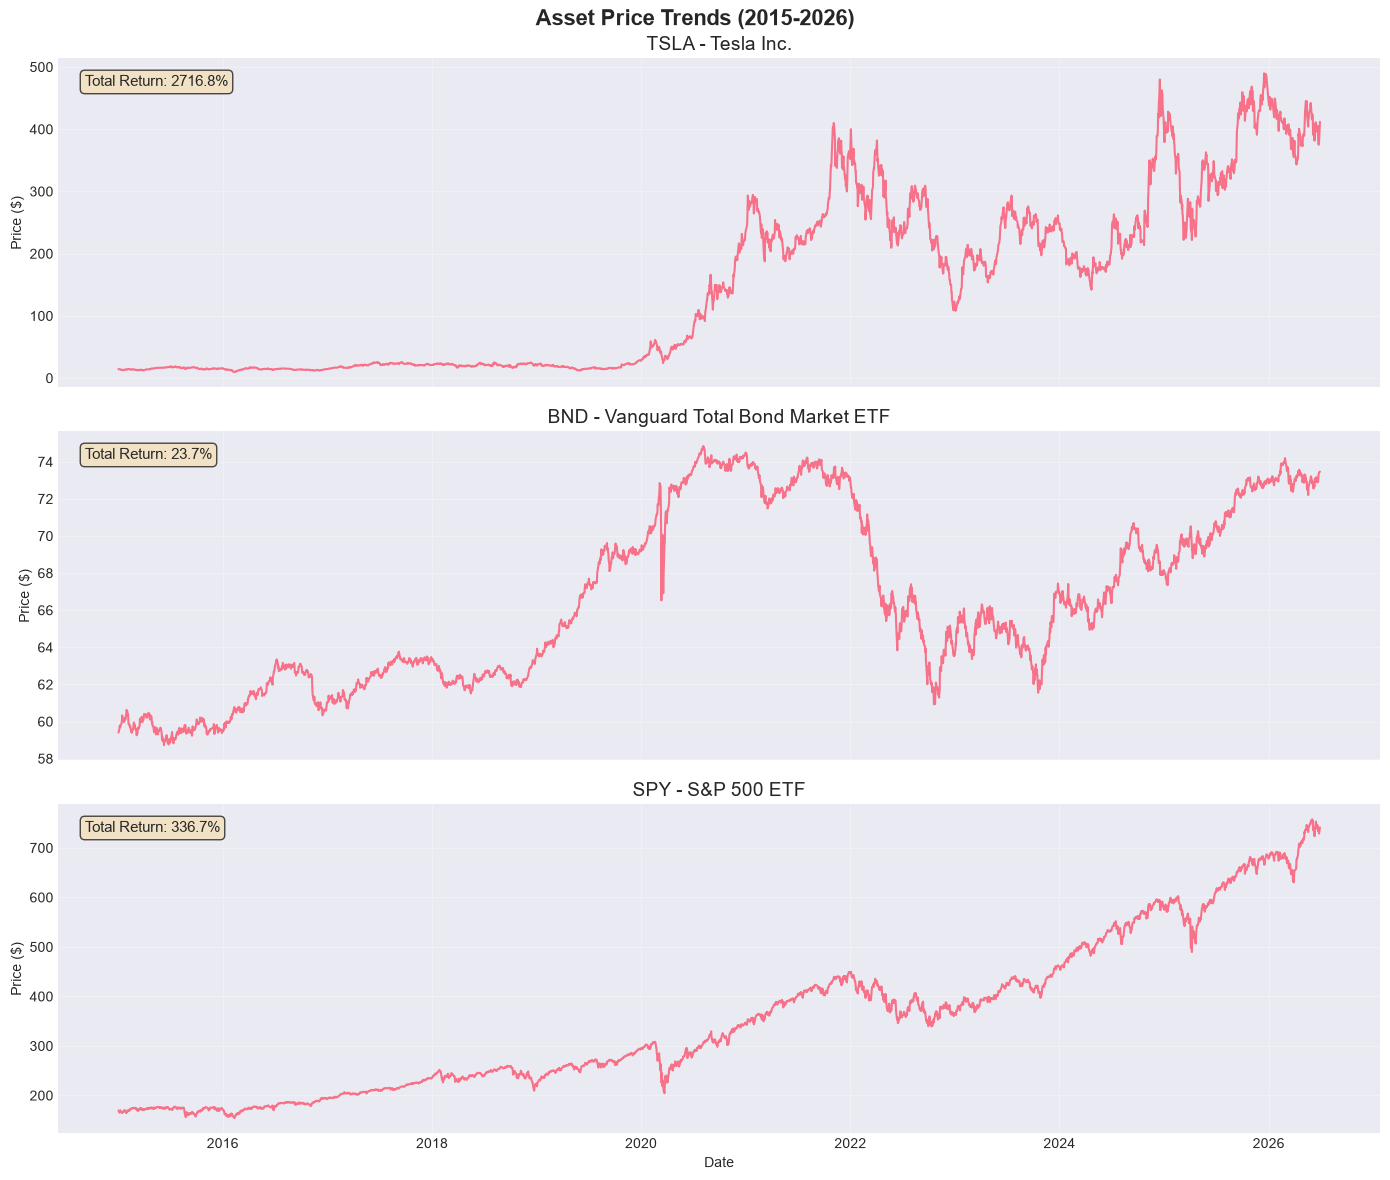

✅ Close prices visualization saved


In [19]:
# --- 3.1: Closing Price Trends ---
print("\n[3.1] Closing Price Trends")
print("-" * 40)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for idx, ticker in enumerate(adj_close_df.columns):
    ax = axes[idx]
    ax.plot(adj_close_df.index, adj_close_df[ticker], linewidth=1.5)
    ax.set_title(f'{ticker} - {ASSETS[ticker]["name"]}', fontsize=14)
    ax.set_ylabel('Price ($)')
    ax.grid(True, alpha=0.3)
    
    # Add annotation
    start_price = adj_close_df[ticker].iloc[0]
    end_price = adj_close_df[ticker].iloc[-1]
    total_return = ((end_price / start_price) - 1) * 100
    ax.text(0.02, 0.95, f'Total Return: {total_return:.1f}%', 
            transform=ax.transAxes, fontsize=11, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

axes[2].set_xlabel('Date')
plt.suptitle('Asset Price Trends (2015-2026)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_close_prices.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Close prices visualization saved")

In [11]:
# Calculate daily percentage returns
returns_df = adj_close_df.pct_change().dropna()

print("📊 Daily Returns DataFrame created!")
print(f"📏 Shape: {returns_df.shape}")
print(f"\nFirst few rows:")
returns_df.head()

print(f"\n📊 Summary statistics for daily returns:")
returns_df.describe()

📊 Daily Returns DataFrame created!
📏 Shape: (0, 3)

First few rows:

📊 Summary statistics for daily returns:


,TSLA,BND,SPY
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN



[3.2] Daily Returns Analysis
----------------------------------------


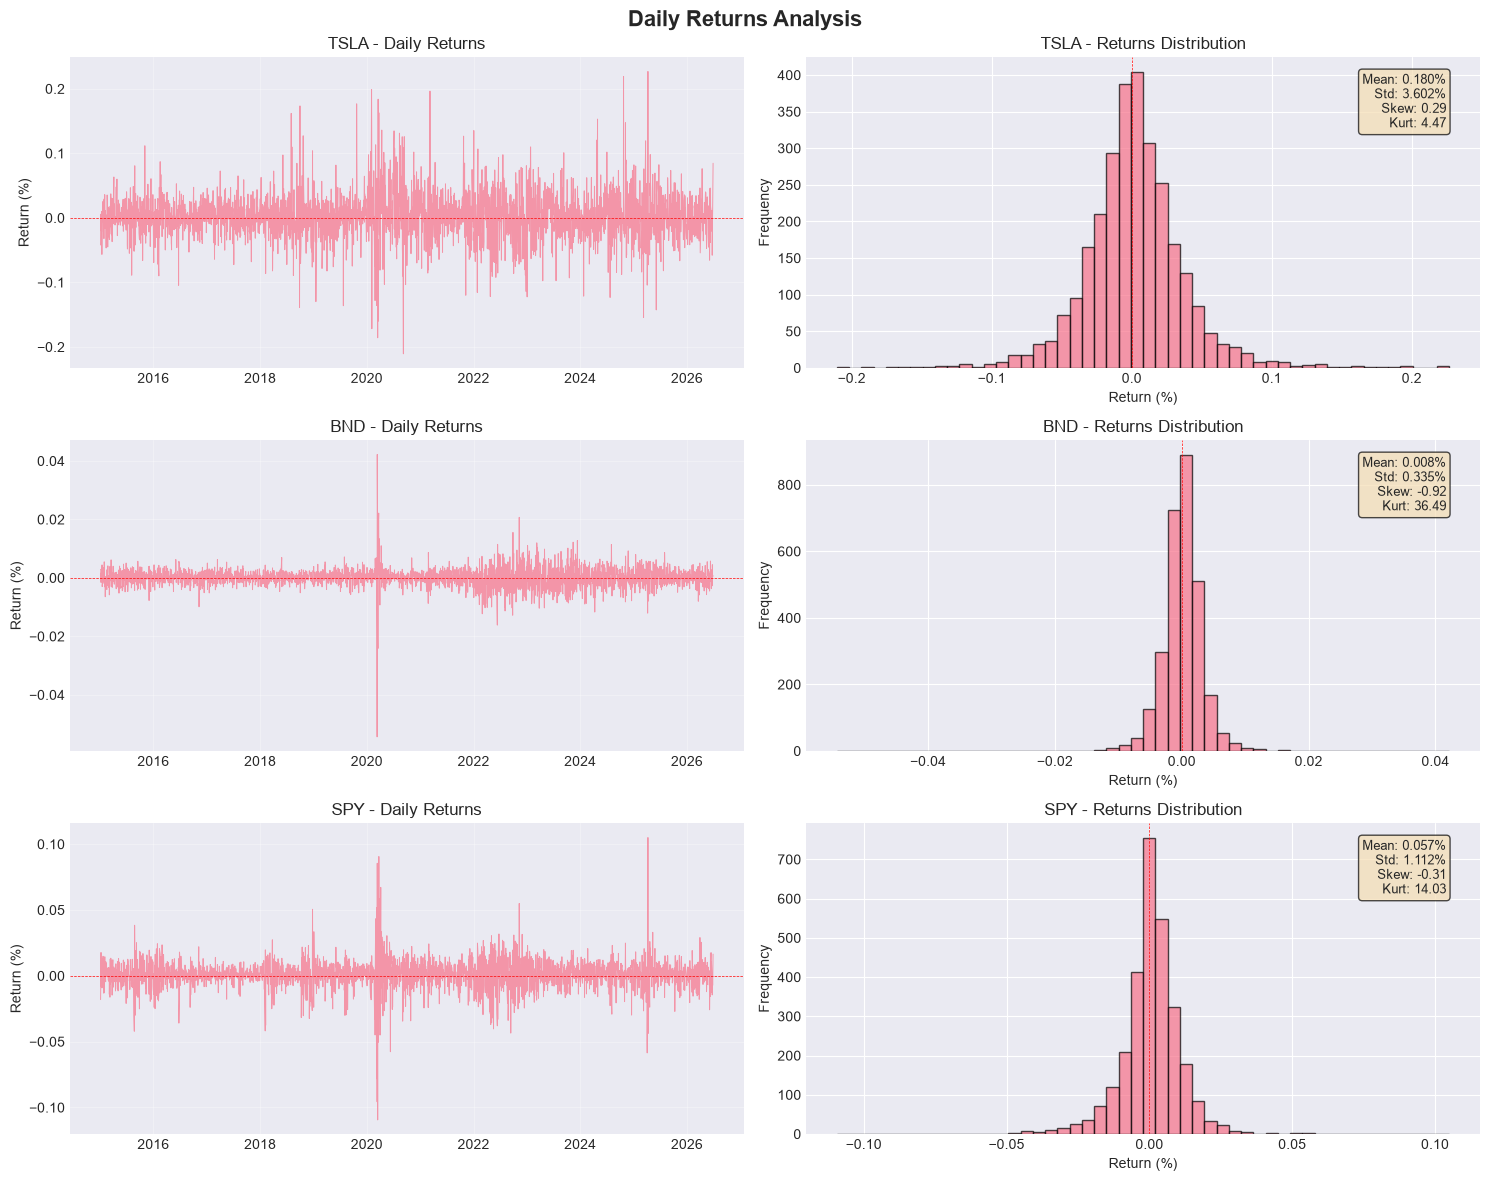

✅ Daily returns visualization saved


In [20]:
# --- 3.2: Daily Returns Analysis ---
print("\n[3.2] Daily Returns Analysis")
print("-" * 40)

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

for idx, ticker in enumerate(returns_df.columns):
    # Returns over time
    ax1 = axes[idx, 0]
    ax1.plot(returns_df.index, returns_df[ticker], linewidth=0.7, alpha=0.7)
    ax1.axhline(y=0, color='red', linestyle='--', linewidth=0.5)
    ax1.set_title(f'{ticker} - Daily Returns')
    ax1.set_ylabel('Return (%)')
    ax1.grid(True, alpha=0.3)
    
    # Returns distribution
    ax2 = axes[idx, 1]
    ax2.hist(returns_df[ticker], bins=50, edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--', linewidth=0.5)
    ax2.set_title(f'{ticker} - Returns Distribution')
    ax2.set_xlabel('Return (%)')
    ax2.set_ylabel('Frequency')
    
    # Add statistics
    mean_return = returns_df[ticker].mean() * 100
    std_return = returns_df[ticker].std() * 100
    skew = returns_df[ticker].skew()
    kurt = returns_df[ticker].kurtosis()
    ax2.text(0.95, 0.95, f'Mean: {mean_return:.3f}%\nStd: {std_return:.3f}%\nSkew: {skew:.2f}\nKurt: {kurt:.2f}',
             transform=ax2.transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('Daily Returns Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_daily_returns.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Daily returns visualization saved")

In [21]:
# --- 3.3: Summary Statistics ---
print("\n[3.3] Summary Statistics")
print("-" * 40)

summary_stats = pd.DataFrame()
for ticker in returns_df.columns:
    summary_stats[ticker] = {
        'Mean Daily Return (%)': returns_df[ticker].mean() * 100,
        'Std Dev (%)': returns_df[ticker].std() * 100,
        'Annualized Volatility (%)': returns_df[ticker].std() * (252 ** 0.5) * 100,
        'Skewness': returns_df[ticker].skew(),
        'Kurtosis': returns_df[ticker].kurtosis(),
        'Min Return (%)': returns_df[ticker].min() * 100,
        'Max Return (%)': returns_df[ticker].max() * 100
    }

print(summary_stats.round(3).to_string())

# Save summary
summary_stats.T.to_csv('../data/processed/eda_summary_stats.csv')
print("\n✅ Summary statistics saved")


[3.3] Summary Statistics
----------------------------------------
                             TSLA     BND     SPY
Mean Daily Return (%)       0.180   0.008   0.057
Std Dev (%)                 3.602   0.335   1.112
Annualized Volatility (%)  57.177   5.314  17.655
Skewness                    0.293  -0.917  -0.308
Kurtosis                    4.467  36.492  14.025
Min Return (%)            -21.063  -5.438 -10.942
Max Return (%)             22.690   4.220  10.502

✅ Summary statistics saved



[3.4] Correlation Analysis
----------------------------------------

Correlation Matrix:
          TSLA       BND       SPY
TSLA  1.000000  0.059361  0.493535
BND   0.059361  1.000000  0.115706
SPY   0.493535  0.115706  1.000000


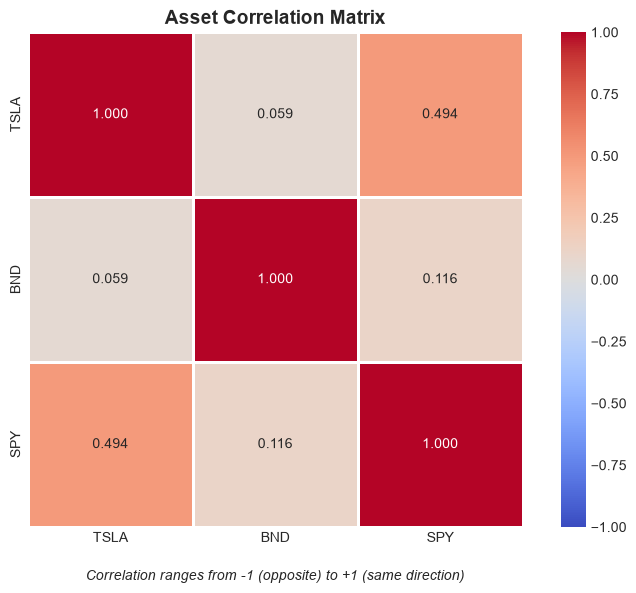

✅ Correlation heatmap saved


In [22]:
# --- 3.4: Correlation Analysis ---
print("\n[3.4] Correlation Analysis")
print("-" * 40)

correlation_matrix = returns_df.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix.to_string())

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=True, linewidths=1, vmin=-1, vmax=1)
plt.title('Asset Correlation Matrix', fontsize=14, fontweight='bold')
plt.text(0.5, -0.1, 'Correlation ranges from -1 (opposite) to +1 (same direction)',
         ha='center', va='center', transform=ax.transAxes, fontsize=10, style='italic')
plt.tight_layout()
plt.savefig('../data/processed/eda_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Correlation heatmap saved")

In [23]:
# ============================================================================
# SECTION 4: STATIONARITY TESTING
# ============================================================================

print("\n" + "=" * 70)
print("STEP 4: STATIONARITY TESTING")
print("=" * 70)

def adf_test_with_interpretation(series, series_name):
    """Perform Augmented Dickey-Fuller test with business interpretation"""
    print(f"\n{'='*50}")
    print(f"ADF Test: {series_name}")
    print(f"{'='*50}")
    
    result = adfuller(series.dropna(), autolag='AIC')
    
    print(f"ADF Statistic: {result[0]:.6f}")
    print(f"p-value: {result[1]:.6f}")
    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.6f}")
    
    is_stationary = result[1] <= 0.05
    
    print(f"\nVerdict: {'✅ REJECT' if is_stationary else '❌ FAIL TO REJECT'} H0")
    print(f"Series is: {'STATIONARY' if is_stationary else 'NON-STATIONARY'}")
    
    if is_stationary:
        print("\n📈 Business Implication:")
        print("  - This series has constant statistical properties over time")
        print("  - Suitable for ARIMA modeling without differencing (d=0)")
        print("  - More predictable for forecasting purposes")
    else:
        print("\n📈 Business Implication:")
        print("  - This series has changing statistical properties over time")
        print("  - Need differencing (d=1) for ARIMA modeling")
        print("  - Price predictions are more challenging")
    
    return result, is_stationary


STEP 4: STATIONARITY TESTING


In [25]:
# Test prices
print("\n[4.1] Testing Closing Prices")
for ticker in returns_df.columns:
    adf_test_with_interpretation(adj_close_df[ticker], f"{ticker} Closing Prices")

# Test returns
print("\n[4.2] Testing Daily Returns")
for ticker in returns_df.columns:
    adf_test_with_interpretation(returns_df[ticker], f"{ticker} Daily Returns")


[4.1] Testing Closing Prices

ADF Test: TSLA Closing Prices
ADF Statistic: -1.069599
p-value: 0.727042

Critical Values:
  1%: -3.432639
  5%: -2.862551
  10%: -2.567308

Verdict: ❌ FAIL TO REJECT H0
Series is: NON-STATIONARY

📈 Business Implication:
  - This series has changing statistical properties over time
  - Need differencing (d=1) for ARIMA modeling
  - Price predictions are more challenging

ADF Test: BND Closing Prices
ADF Statistic: -1.082705
p-value: 0.721920

Critical Values:
  1%: -3.432627
  5%: -2.862546
  10%: -2.567306

Verdict: ❌ FAIL TO REJECT H0
Series is: NON-STATIONARY

📈 Business Implication:
  - This series has changing statistical properties over time
  - Need differencing (d=1) for ARIMA modeling
  - Price predictions are more challenging

ADF Test: SPY Closing Prices
ADF Statistic: 1.308944
p-value: 0.996659

Critical Values:
  1%: -3.432624
  5%: -2.862545
  10%: -2.567305

Verdict: ❌ FAIL TO REJECT H0
Series is: NON-STATIONARY

📈 Business Implication:
  -

In [26]:
# --- 4.3: Summary ---
print("\n[4.3] Stationarity Summary")
print("-" * 40)

stationarity_summary = pd.DataFrame()
for ticker in returns_df.columns:
    result_prices = adfuller(adj_close_df[ticker].dropna(), autolag='AIC')
    result_returns = adfuller(returns_df[ticker].dropna(), autolag='AIC')
    
    stationarity_summary[ticker] = {
        'Prices Stationary': '✅' if result_prices[1] <= 0.05 else '❌',
        'Prices p-value': result_prices[1],
        'Returns Stationary': '✅' if result_returns[1] <= 0.05 else '❌',
        'Returns p-value': result_returns[1],
        'd needed for ARIMA': 0 if result_returns[1] <= 0.05 else 1
    }

print(stationarity_summary.T.to_string())
stationarity_summary.T.to_csv('../data/processed/stationarity_summary.csv')

print("\n✅ Stationarity results saved")


[4.3] Stationarity Summary
----------------------------------------
     Prices Stationary Prices p-value Returns Stationary Returns p-value d needed for ARIMA
TSLA                 ❌       0.727042                  ✅             0.0                  0
BND                  ❌        0.72192                  ✅             0.0                  0
SPY                  ❌       0.996659                  ✅             0.0                  0

✅ Stationarity results saved


In [27]:
# ============================================================================
# SECTION 5: RISK METRICS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 5: RISK METRICS")
print("=" * 70)

# --- 5.1: Value at Risk (VaR) ---
print("\n[5.1] Value at Risk (VaR) Analysis")
print("-" * 40)

def calculate_var(returns, confidence_level=0.95):
    var = np.percentile(returns, (1 - confidence_level) * 100)
    return var

print("95% VaR (Daily):")
print("-" * 30)
for ticker in returns_df.columns:
    var_95 = calculate_var(returns_df[ticker])
    var_99 = calculate_var(returns_df[ticker], 0.99)
    print(f"\n{ticker}:")
    print(f"  95% Confidence: -{var_95*100:.2f}% daily loss")
    print(f"  99% Confidence: -{var_99*100:.2f}% daily loss")
    
    var_annual = var_95 * (252 ** 0.5)
    print(f"  Annualized VaR (95%): -{var_annual*100:.2f}% loss")


STEP 5: RISK METRICS

[5.1] Value at Risk (VaR) Analysis
----------------------------------------
95% VaR (Daily):
------------------------------

TSLA:
  95% Confidence: --5.17% daily loss
  99% Confidence: --8.99% daily loss
  Annualized VaR (95%): --82.01% loss

BND:
  95% Confidence: --0.48% daily loss
  99% Confidence: --0.86% daily loss
  Annualized VaR (95%): --7.55% loss

SPY:
  95% Confidence: --1.67% daily loss
  99% Confidence: --3.17% daily loss
  Annualized VaR (95%): --26.43% loss


In [28]:
# --- 5.2: Sharpe Ratio ---
print("\n[5.2] Sharpe Ratio Analysis")
print("-" * 40)

def calculate_sharpe(returns, risk_free_rate=0.01):
    annual_return = returns.mean() * 252
    annual_volatility = returns.std() * (252 ** 0.5)
    sharpe = (annual_return - risk_free_rate) / annual_volatility
    return sharpe

print("Sharpe Ratios (Risk-Free Rate: 1%):")
print("-" * 30)
sharpe_ratios = {}
for ticker in returns_df.columns:
    sharpe = calculate_sharpe(returns_df[ticker])
    sharpe_ratios[ticker] = sharpe
    print(f"{ticker}: {sharpe:.3f}")

print(f"\n🏆 Best performer: {max(sharpe_ratios, key=sharpe_ratios.get)}")


[5.2] Sharpe Ratio Analysis
----------------------------------------
Sharpe Ratios (Risk-Free Rate: 1%):
------------------------------
TSLA: 0.777
BND: 0.187
SPY: 0.761

🏆 Best performer: TSLA


In [29]:
# --- 5.3: Maximum Drawdown ---
print("\n[5.3] Maximum Drawdown Analysis")
print("-" * 40)

def calculate_max_drawdown(prices):
    peak = prices.expanding().max()
    drawdown = (prices / peak) - 1
    max_drawdown = drawdown.min()
    return max_drawdown

for ticker in adj_close_df.columns:
    max_dd = calculate_max_drawdown(adj_close_df[ticker])
    print(f"{ticker}: {max_dd*100:.2f}% max drawdown")


[5.3] Maximum Drawdown Analysis
----------------------------------------
TSLA: -73.63% max drawdown
BND: -18.58% max drawdown
SPY: -33.72% max drawdown


In [30]:
# --- 5.4: Risk Metrics Summary ---
print("\n[5.4] Risk Metrics Summary")
print("-" * 40)

risk_summary = pd.DataFrame()
for ticker in returns_df.columns:
    risk_summary[ticker] = {
        'Annualized Return (%)': returns_df[ticker].mean() * 252 * 100,
        'Annualized Volatility (%)': returns_df[ticker].std() * (252 ** 0.5) * 100,
        'Sharpe Ratio': calculate_sharpe(returns_df[ticker]),
        'VaR 95% (%)': calculate_var(returns_df[ticker]) * 100,
        'Max Drawdown (%)': calculate_max_drawdown(adj_close_df[ticker]) * 100
    }

print(risk_summary.T.round(3).to_string())
risk_summary.T.to_csv('../data/processed/risk_metrics_summary.csv')

print("\n✅ Risk metrics saved")


[5.4] Risk Metrics Summary
----------------------------------------
      Annualized Return (%)  Annualized Volatility (%)  Sharpe Ratio  VaR 95% (%)  Max Drawdown (%)
TSLA                 45.424                     57.177         0.777       -5.166           -73.632
BND                   1.996                      5.314         0.187       -0.476           -18.582
SPY                  14.432                     17.655         0.761       -1.665           -33.717

✅ Risk metrics saved


In [31]:
# ============================================================================
# SECTION 6: BUSINESS SUMMARY AND RECOMMENDATIONS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 6: BUSINESS SUMMARY AND RECOMMENDATIONS")
print("=" * 70)

print("\n📊 EXECUTIVE SUMMARY:")
print("-" * 40)

for ticker in adj_close_df.columns:
    start = adj_close_df[ticker].iloc[0]
    end = adj_close_df[ticker].iloc[-1]
    ret = ((end / start) - 1) * 100
    vol = returns_df[ticker].std() * (252 ** 0.5) * 100
    sharpe = sharpe_ratios[ticker]
    var_95 = calculate_var(returns_df[ticker]) * 100
    
    print(f"\n{ticker} - {ASSETS[ticker]['name']}:")
    print(f"  Role: {ASSETS[ticker]['role']}")
    print(f"  Total Return: {ret:.1f}%")
    print(f"  Volatility: {vol:.1f}%")
    print(f"  Sharpe Ratio: {sharpe:.3f}")
    print(f"  95% VaR: {var_95:.2f}%")

print("\n" + "=" * 70)
print("✅ TASK 1 COMPLETE")
print("=" * 70)


STEP 6: BUSINESS SUMMARY AND RECOMMENDATIONS

📊 EXECUTIVE SUMMARY:
----------------------------------------

TSLA - Tesla Inc.:
  Role: Growth driver
  Total Return: 2716.8%
  Volatility: 57.2%
  Sharpe Ratio: 0.777
  95% VaR: -5.17%

BND - Vanguard Total Bond Market ETF:
  Role: Portfolio stabilizer
  Total Return: 23.7%
  Volatility: 5.3%
  Sharpe Ratio: 0.187
  95% VaR: -0.48%

SPY - S&P 500 ETF:
  Role: Market core holding
  Total Return: 336.7%
  Volatility: 17.7%
  Sharpe Ratio: 0.761
  95% VaR: -1.67%

✅ TASK 1 COMPLETE
